# lightcurves/ep250615a

迁移自 / Migrated from `test/test_lightcurve.ipynb`.

状态 / Status: **legacy_analysis**. 真实观测分析记录，旧字段和时间约定尚未重审 / Historical analysis; field and time contracts need review

历史输出保留，不代表迁移后重新验证；原报错数量 / Preserved historical errors: 0.
Historical outputs are retained and are not evidence of a new successful run.

输入路径在下一单元集中配置；原始数据留在原位置。
Input roots are configured below; original data remain in place.


In [ ]:
# 从仓库定位输入，允许通过环境变量覆盖；不移动原始数据。
# Locate repository inputs with environment overrides; original data stay in place.
from pathlib import Path
from datetime import datetime, timezone
import os
_anchor = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
REPO_ROOT = next((p for p in (_anchor, *_anchor.parents)
                  if (p/'packages/jinwu').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError('请从 JinWu 仓库内运行 / Run from within the JinWu checkout')
RESEARCH_ROOT = Path(os.environ.get('JINWU_EXAMPLE_RESEARCH_ROOT', REPO_ROOT.parent))
TEST_DATA_ROOT = Path(os.environ.get('JINWU_EXAMPLE_TEST_ROOT', REPO_ROOT/'test'))
DOWNLOAD_ROOT = Path(os.environ.get('JINWU_EXAMPLE_DOWNLOAD_ROOT', Path.home()/'下载'))
# 图件写入独立运行目录，不覆盖研究目录中的历史图。
# Write figures into a unique run directory, preserving historical research plots.
OUTPUT_DIR = Path(os.environ.get('JINWU_EXAMPLE_OUTPUT_ROOT', REPO_ROOT/'examples/_outputs')) / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)


In [ ]:
import jinwu
from jinwu.core.time import Time
from jinwu.core import readfits, netdata
from pathlib import Path
import numpy as np

In [ ]:
srclcpath = Path(str(RESEARCH_ROOT / 'ep250615a/ep/ep11900273154wxt37s1.lc'))
bkglcpath = Path(str(RESEARCH_ROOT / 'ep250615a/ep/ep11900273154wxt37s1bk.lc'))
batlcpath = Path(str(RESEARCH_ROOT / 'ep250615a/01324646000/bat/event/ep250615a.lc'))
cmos14srcpath = Path(str(RESEARCH_ROOT / 'ep250615a/cmos14/ep11900273154wxt14s1.lc'))
cmos14bkgpath = Path(str(RESEARCH_ROOT / 'ep250615a/cmos14/ep11900273154wxt14s1bk.lc'))

In [ ]:
bkglc = readfits(bkglcpath)
srclc = readfits(srclcpath)
batlc = readfits(batlcpath)
src14lc = readfits(cmos14srcpath)
bkg14lc = readfits(cmos14bkgpath)

In [ ]:
wxtlc = netdata(source=srclc, background=bkglc, label='WXTcmos37')
lc14 = netdata(source=src14lc, background=bkg14lc, label='WXTcmos14')

In [ ]:
wxtlc.data.meta.timezero

172189118.3999

In [ ]:
wxtlc.area_ratio

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
wxttimezero = srclc.meta.timezero

In [ ]:
cmos14timezero = src14lc.meta.timezero

In [ ]:
trigtime = batlc.header['TRIGTIME']

In [ ]:
trigtime = Time(trigtime,format='swift')
wxttimezero = Time(wxttimezero,format='ep')
cmos14timezero = Time(cmos14timezero, format='ep')

In [ ]:
battime = batlc.time - trigtime.swift

In [ ]:
batrate = batlc.rate
baterror = batlc.error
batxerr = batlc.dt/2

In [ ]:
batrate

array([[ 0.0080304 , -0.00098369, -0.00553956,  0.01391446],
       [ 0.00509131, -0.0016586 , -0.00309913, -0.00554836],
       [-0.00759117, -0.01093689, -0.00321934, -0.00781778],
       ...,
       [ 0.0052863 ,  0.00669564,  0.00440438, -0.00951968],
       [-0.00354114,  0.00496407,  0.00735162, -0.00316292],
       [ 0.00445814, -0.00666556, -0.00498348, -0.0084976 ]],
      shape=(1202, 4))

In [ ]:
# 假设 batrate, baterror 形状为 (N, 4)
if batrate.ndim == 2 and batrate.shape[1] == 4:
    batrate_sum = batrate.sum(axis=1)
    baterror_sum = np.sqrt((baterror ** 2).sum(axis=1))
else:
    batrate_sum = batrate
    baterror_sum = baterror

In [ ]:
batrate_sum = batrate_sum.tolist()
baterror_sum = baterror_sum.tolist()

In [ ]:
wxtlc.data.time

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 1.231e+03, 1.232e+03,
       1.233e+03], shape=(1234,))

In [ ]:
lc14.time

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 1.231e+03, 1.232e+03,
       1.233e+03], shape=(1234,))

In [ ]:
wxttime = wxtlc.data.time + (wxttimezero - trigtime).sec

In [ ]:
cmos14time = lc14.data.time + (wxttimezero - trigtime).sec

In [ ]:
wxttime = wxttime.tolist()
cmos14time = cmos14time.tolist()

In [ ]:
wxtrate = wxtlc.data.rate.tolist()
wxterror = wxtlc.data.error.tolist()
wxtxerr = wxtlc.dt / 2

In [ ]:
cmos14rate = lc14.data.rate.tolist()
cmos14error = lc14.data.error.tolist()
cmos14xerr = lc14.dt / 2

In [ ]:
batt90start = Time('2025-06-15T22:25:16.206', scale='utc')
batt90stop = Time('2025-06-15T22:26:06.866', scale='utc')

t90left = (batt90start - trigtime).sec
t90right = (batt90stop - trigtime).sec

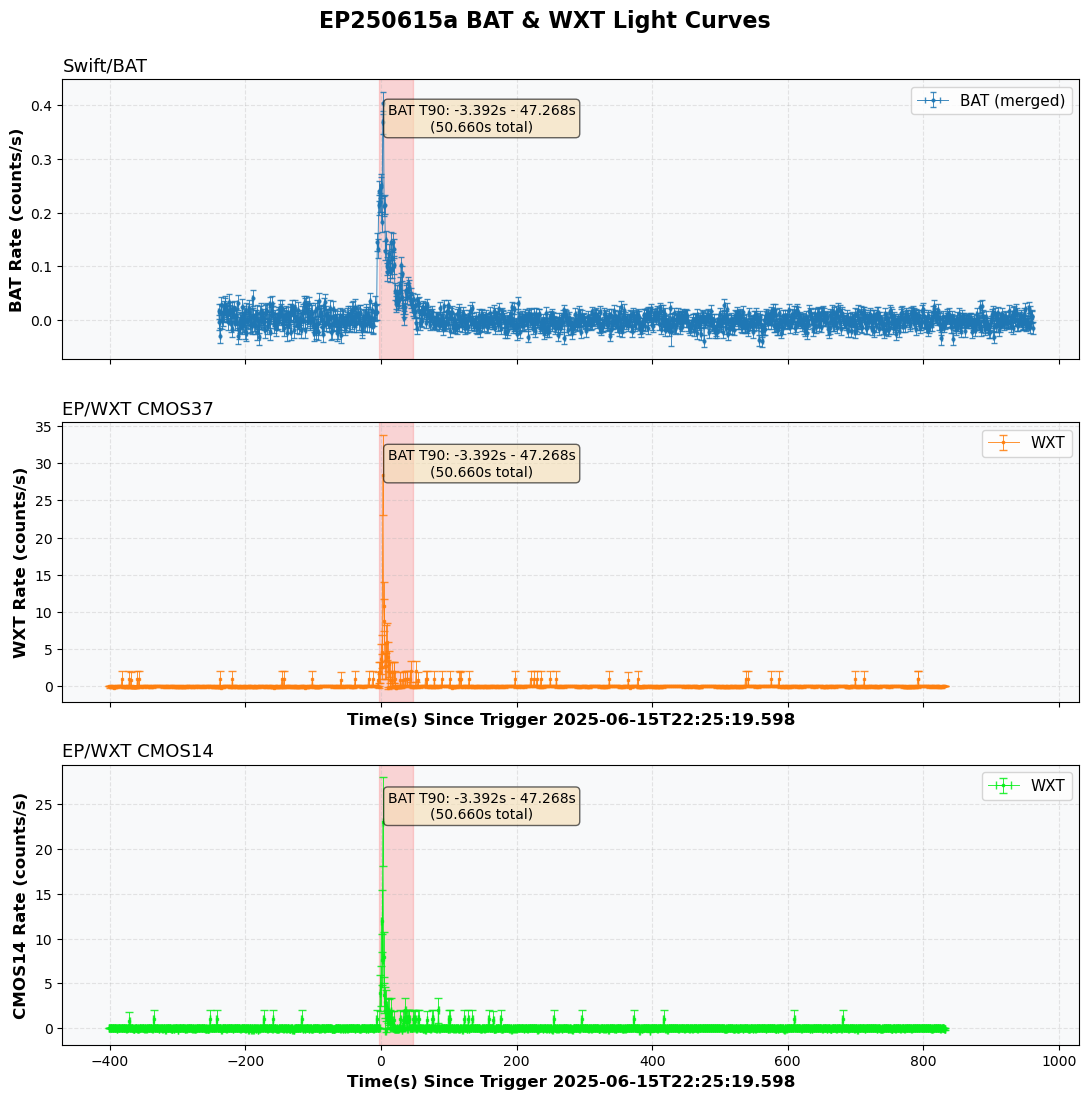

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(11,11), sharex=True)
fig.suptitle('EP250615a BAT & WXT Light Curves', fontsize=16, fontweight='bold', y=0.995)

# Calculate T90 duration
t90_duration = t90right - t90left
t90_label = f'BAT T90: {t90left:.3f}s - {t90right:.3f}s\n({t90_duration:.3f}s total)'

# BAT light curve
axs[0].errorbar(battime, batrate_sum, yerr=baterror_sum, xerr = batxerr, fmt='o-', color='#1f77b4', 
                capsize=2, elinewidth=0.7, linewidth=0.7, markersize=2, label='BAT (merged)', alpha=0.85)
axs[0].set_ylabel('BAT Rate (counts/s)', fontsize=12, fontweight='bold')
axs[0].set_title('Swift/BAT', fontsize=13, loc='left')
axs[0].grid(True, alpha=0.3, linestyle='--')
axs[0].legend(fontsize=11, loc='upper right')
axs[0].set_facecolor('#f8f9fa')
# Add T90 shaded region with label
axs[0].axvspan(t90left, t90right, alpha=0.15, color='red')
label_x = t90left + (t90right - t90left) *3
axs[0].text(label_x, axs[0].get_ylim()[1] * 0.9, t90_label, 
            ha='center', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# WXT light curve
axs[1].errorbar(wxttime, wxtrate, yerr=wxterror, fmt='s-', color='#ff7f0e', 
                capsize=3, elinewidth=0.7, linewidth=0.7, markersize=2, label='WXT', alpha=0.85)
axs[1].set_xlabel(f'Time(s) Since Trigger {trigtime.utc.isot}', fontsize=12, fontweight='bold')
axs[1].set_ylabel('WXT Rate (counts/s)', fontsize=12, fontweight='bold')
axs[1].set_title('EP/WXT CMOS37', fontsize=13, loc='left')
axs[1].grid(True, alpha=0.3, linestyle='--')
axs[1].legend(fontsize=11, loc='upper right')
axs[1].set_facecolor('#f8f9fa')
# Add T90 shaded region with label
axs[1].axvspan(t90left, t90right, alpha=0.15, color='red')
axs[1].text(label_x, axs[1].get_ylim()[1] * 0.9, t90_label, 
            ha='center', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))


axs[2].errorbar(cmos14time, cmos14rate, yerr=cmos14error,xerr=cmos14xerr,fmt='s-', color="#08ee1b", 
                capsize=3, elinewidth=0.7, linewidth=0.7, markersize=2, label='WXT', alpha=0.85)
axs[2].set_xlabel(f'Time(s) Since Trigger {trigtime.utc.isot}', fontsize=12, fontweight='bold')
axs[2].set_ylabel('CMOS14 Rate (counts/s)', fontsize=12, fontweight='bold')
axs[2].set_title('EP/WXT CMOS14 ', fontsize=13, loc='left')
axs[2].grid(True, alpha=0.3, linestyle='--')
axs[2].legend(fontsize=11, loc='upper right')
axs[2].set_facecolor('#f8f9fa')
# Add T90 shaded region with label
axs[2].axvspan(t90left, t90right, alpha=0.15, color='red')
axs[2].text(label_x, axs[2].get_ylim()[1] * 0.9, t90_label, 
            ha='center', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))


plt.savefig(str(OUTPUT_DIR / 'ep250615a_lightcurves.png'), dpi=300)
plt.savefig(str(OUTPUT_DIR / 'ep250615a_lightcurves.svg'), dpi=300)
plt.tight_layout()

In [ ]:
t90left

np.float64(-3.3924560251151092)

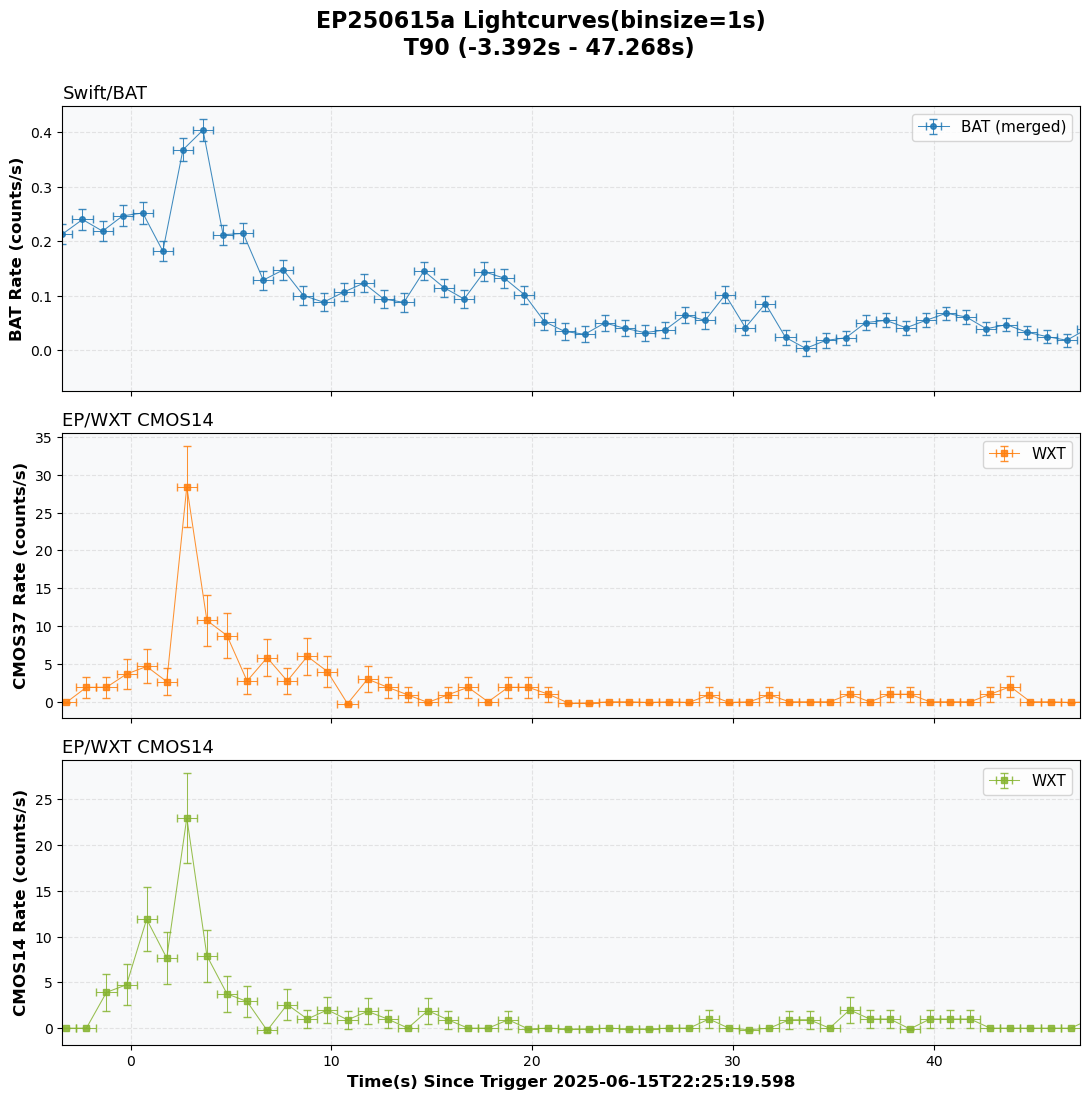

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
fig.suptitle(f'EP250615a Lightcurves(binsize=1s) \n T90 ({t90left:.3f}s - {t90right:.3f}s)', fontsize=16, fontweight='bold', y=0.995)

# BAT light curve
axs[0].errorbar(battime, batrate_sum, yerr=baterror_sum,xerr=batxerr, fmt='o-', color='#1f77b4', 
                capsize=3, elinewidth=0.75, linewidth=0.75, markersize=4, label='BAT (merged)', alpha=0.85)
axs[0].set_ylabel('BAT Rate (counts/s)', fontsize=12, fontweight='bold')
axs[0].set_title('Swift/BAT', fontsize=13, loc='left')
axs[0].grid(True, alpha=0.3, linestyle='--')
axs[0].legend(fontsize=11, loc='upper right')
axs[0].set_facecolor('#f8f9fa')
# Add T90 shaded region
# axs[0].axvspan(t90left, t90right, alpha=0.15, color='red', label='T90')

# WXT light curve
axs[1].errorbar(wxttime, wxtrate, yerr=wxterror,xerr=wxtxerr, fmt='s-', color='#ff7f0e', 
                capsize=3, elinewidth=0.75, linewidth=0.75, markersize=4, label='WXT', alpha=0.85)
# axs[1].set_xlabel(f'Time(s) Since Trigger {trigtime.utc.isot}', fontsize=12, fontweight='bold')
axs[1].set_ylabel('CMOS37 Rate (counts/s)', fontsize=12, fontweight='bold')
axs[1].set_title('EP/WXT CMOS14', fontsize=13, loc='left')
axs[1].grid(True, alpha=0.3, linestyle='--')
axs[1].legend(fontsize=11, loc='upper right')
axs[1].set_facecolor('#f8f9fa')
# Add T90 shaded region
# axs[1].axvspan(t90left, t90right, alpha=0.15, color='red', label='T90')
axs[2].errorbar(cmos14time, cmos14rate, yerr=cmos14error,xerr=cmos14xerr,fmt='s-', color="#86b430", 
                capsize=3, elinewidth=0.75, linewidth=0.75, markersize=4, label='WXT', alpha=0.85)
axs[2].set_xlabel(f'Time(s) Since Trigger {trigtime.utc.isot}', fontsize=12, fontweight='bold')
axs[2].set_ylabel('CMOS14 Rate (counts/s)', fontsize=12, fontweight='bold')
axs[2].set_title('EP/WXT CMOS14 ', fontsize=13, loc='left')
axs[2].grid(True, alpha=0.3, linestyle='--')
axs[2].legend(fontsize=11, loc='upper right')
axs[2].set_facecolor('#f8f9fa')
# Add T90 shaded region with label

for ax in axs:
    ax.set_xlim(t90left, t90right)
plt.savefig(str(OUTPUT_DIR / 'ep250615a_t90_lightcurves.png'), dpi=300)
plt.savefig(str(OUTPUT_DIR / 'ep250615a_t90_lightcurves.svg'), dpi=300)
plt.tight_layout()

Saved: /home/xinxiang/research/ep250615a/ep250615a_bat_segments_subplots.png


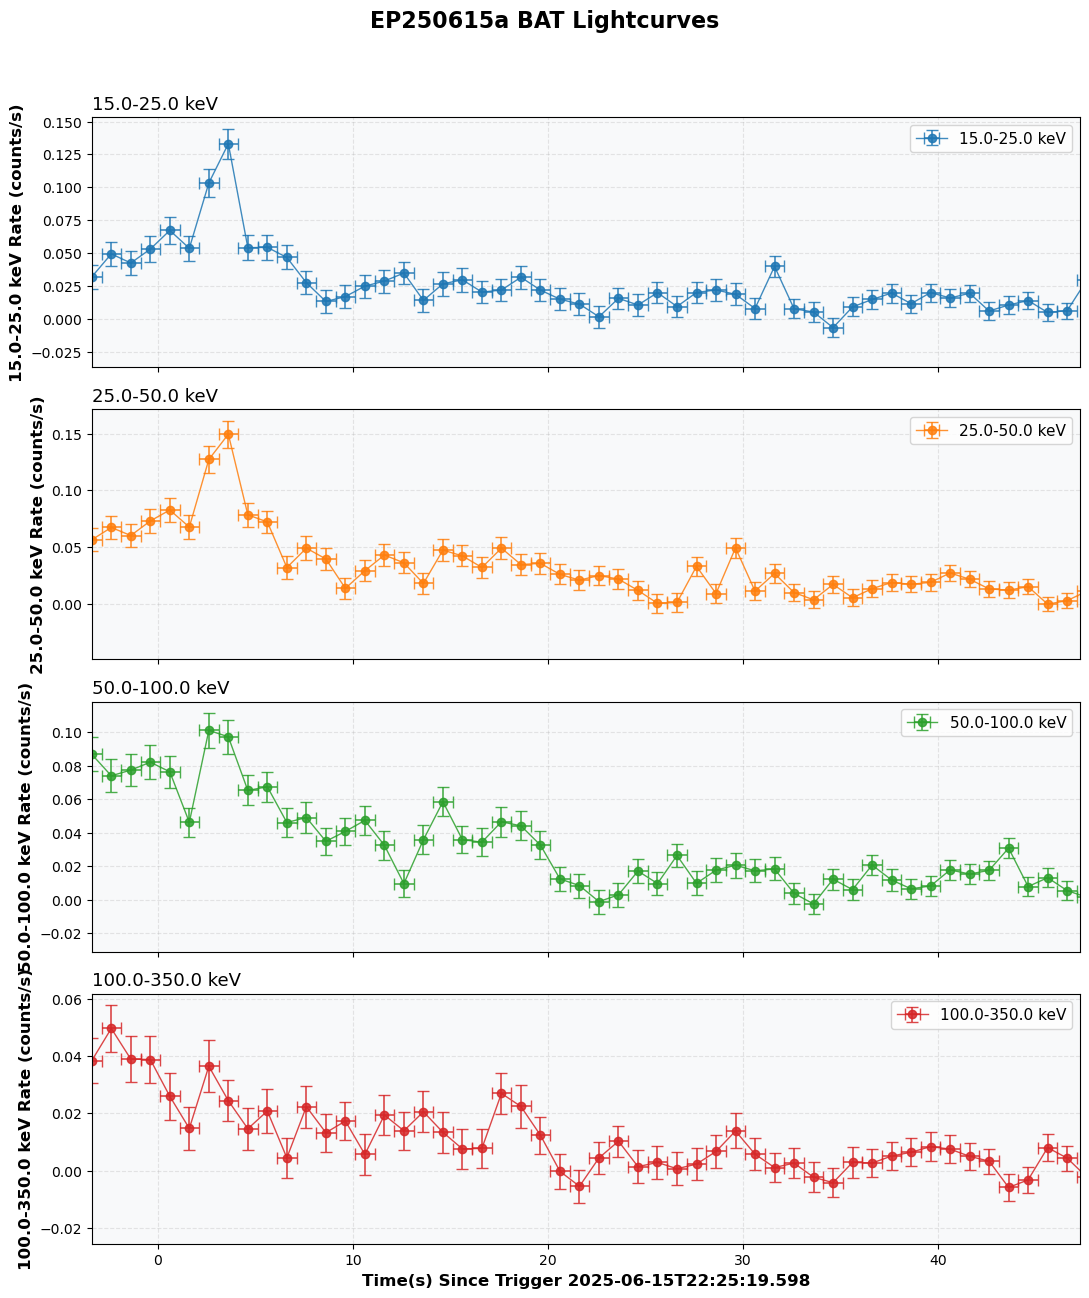

In [ ]:

# 绘制 BAT 四个能段分别在四个子图
import os
import numpy as np
import matplotlib.pyplot as plt

# 容错获取 batrate 与时间
if 'batrate' not in globals():
    raise RuntimeError('未找到变量 `batrate`，请先运行读取 BAT 数据的单元')

batrate_arr = np.asarray(batrate)
if batrate_arr.ndim == 2 and batrate_arr.shape[1] == 4:
    seg = batrate_arr
elif batrate_arr.ndim == 1:
    if batrate_arr.size % 4 == 0:
        seg = batrate_arr.reshape(-1, 4)
    else:
        raise RuntimeError('`batrate` 为一维但长度不能被4整除，无法重塑为 (N,4)')
else:
    raise RuntimeError('`batrate` 形状无法识别，请提供形状 (N,4) 或可重塑为该形状的一维数组')

# 时间与误差
if 'battime' in globals():
    times = np.asarray(battime)
else:
    times = np.arange(seg.shape[0])

xerr = np.asarray(globals().get('batxerr', np.zeros_like(times)))

# 计算每个能段的误差
if 'baterror' in globals():
    ber = np.asarray(baterror)
    if ber.ndim == 2 and ber.shape[1] == 4:
        yerr = ber
    else:
        yerr = np.zeros_like(seg)
else:
    yerr = np.zeros_like(seg)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels = ['15.0-25.0 keV', '25.0-50.0 keV', '50.0-100.0 keV', '100.0-350.0 keV']
marker_size = 6
line_width = 1.0
err_linewidth = 1.2
capsize = 4

fig, axs = plt.subplots(4, 1, figsize=(11, 13), sharex=True)
fig.suptitle('EP250615a BAT Lightcurves', fontsize=16, fontweight='bold', y=0.995)

for i in range(4):
    axs[i].errorbar(times, seg[:, i], yerr=yerr[:, i], xerr=xerr, fmt='o-', color=colors[i],
                    capsize=capsize, elinewidth=err_linewidth, linewidth=line_width, markersize=marker_size, label=labels[i], alpha=0.85)
    axs[i].set_ylabel(f'{labels[i]} Rate (counts/s)', fontsize=12, fontweight='bold')
    axs[i].set_title(labels[i], fontsize=13, loc='left')
    axs[i].grid(True, alpha=0.3, linestyle='--')
    axs[i].legend(fontsize=11, loc='upper right')
    axs[i].set_facecolor('#f8f9fa')

axs[-1].set_xlabel(f"Time(s) Since Trigger {trigtime.utc.isot if 'trigtime' in globals() else ''}", fontsize=12, fontweight='bold')
for ax in axs:
    ax.set_xlim(t90left, t90right)
plt.tight_layout(rect=[0, 0, 1, 0.97])
outpath = os.path.join( str(OUTPUT_DIR / 'ep250615a_bat_segments_subplots.png'))
plt.savefig(outpath, dpi=300)
print('Saved:', outpath)
plt.show()

Saved: /home/xinxiang/research/ep250615a/ep250615a_bat_wxt_combined_en_contrast.png


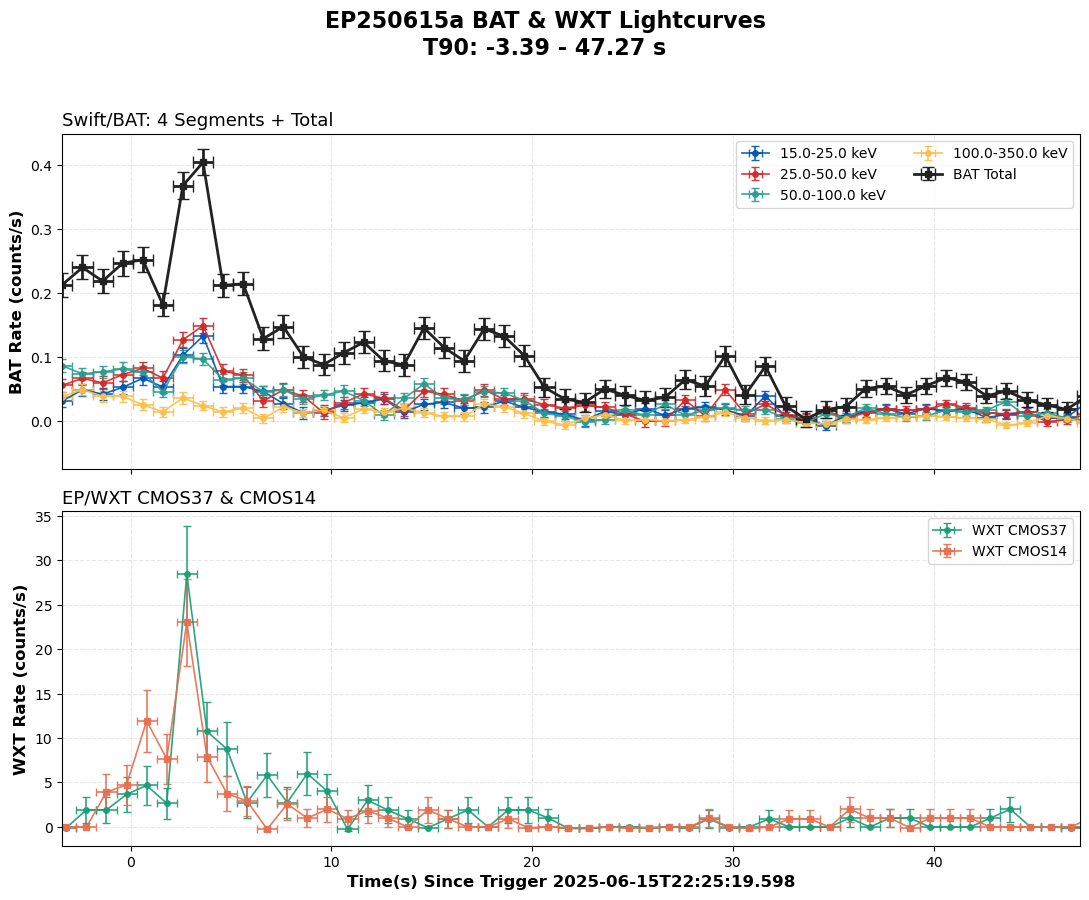

In [ ]:
# Combined Lightcurves: BAT (4 segments + total) & WXT CMOS37/CMOS14, T90 in title, high-contrast colors
import os
import numpy as np
import matplotlib.pyplot as plt

# BAT segments and total
batrate_arr = np.asarray(batrate)
if batrate_arr.ndim == 2 and batrate_arr.shape[1] == 4:
    seg = batrate_arr
elif batrate_arr.ndim == 1:
    if batrate_arr.size % 4 == 0:
        seg = batrate_arr.reshape(-1, 4)
    else:
        raise RuntimeError('`batrate` must be shape (N,4) or 1D with length divisible by 4')
else:
    raise RuntimeError('`batrate` shape not recognized')

times = np.asarray(battime)
xerr = np.asarray(batxerr)
total = seg.sum(axis=1)

# Error bars
if 'baterror' in globals():
    ber = np.asarray(baterror)
    if ber.ndim == 2 and ber.shape[1] == 4:
        yerr = ber
        yerr_total = np.sqrt((ber ** 2).sum(axis=1))
    else:
        yerr = np.zeros_like(seg)
        yerr_total = np.zeros_like(total)
else:
    yerr = np.zeros_like(seg)
    yerr_total = np.zeros_like(total)

# High-contrast colors for white background
bat_colors = ['#0057b7', '#d62828', '#2a9d8f', '#fcbf49'] # blue, red, teal, yellow
bat_labels = ['15.0-25.0 keV', '25.0-50.0 keV', '50.0-100.0 keV', '100.0-350.0 keV']
bat_total_color = '#222222' # dark gray/black

wxt_color = '#1b9e77' # green
cmos14_color = '#e76f51' # orange

fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
fig.suptitle(f'EP250615a BAT & WXT Lightcurves\nT90: {t90left:.2f} - {t90right:.2f} s', fontsize=16, fontweight='bold', y=0.995)

# BAT segments and total (subplot 1)
for i in range(4):
    axs[0].errorbar(times, seg[:, i], yerr=yerr[:, i], xerr=xerr, fmt='o-', color=bat_colors[i],
                    capsize=3, elinewidth=1.2, linewidth=1.2, markersize=4, label=bat_labels[i], alpha=0.92)
axs[0].errorbar(times, total, yerr=yerr_total, xerr=xerr, fmt='s-', color=bat_total_color,
                capsize=4, elinewidth=2.0, linewidth=2.0, markersize=5, label='BAT Total', alpha=1.0)
axs[0].set_ylabel('BAT Rate (counts/s)', fontsize=12, fontweight='bold')
axs[0].set_title('Swift/BAT: 4 Segments + Total', fontsize=13, loc='left')
axs[0].grid(True, alpha=0.3, linestyle='--')
axs[0].legend(fontsize=10, loc='upper right', ncol=2)
axs[0].set_facecolor('#ffffff')

# WXT CMOS37 & CMOS14 (subplot 2, high-contrast colors)
axs[1].errorbar(wxttime, wxtrate, yerr=wxterror, xerr=wxtxerr, fmt='o-', color=wxt_color,
                capsize=3, elinewidth=1.2, linewidth=1.2, markersize=4, label='WXT CMOS37', alpha=0.92)
axs[1].errorbar(cmos14time, cmos14rate, yerr=cmos14error, xerr=cmos14xerr, fmt='s-', color=cmos14_color,
                capsize=3, elinewidth=1.2, linewidth=1.2, markersize=4, label='WXT CMOS14', alpha=0.92)
axs[1].set_xlabel(f'Time(s) Since Trigger {trigtime.utc.isot}', fontsize=12, fontweight='bold')
axs[1].set_ylabel('WXT Rate (counts/s)', fontsize=12, fontweight='bold')
axs[1].set_title('EP/WXT CMOS37 & CMOS14', fontsize=13, loc='left')
axs[1].grid(True, alpha=0.3, linestyle='--')
axs[1].legend(fontsize=10, loc='upper right')
axs[1].set_facecolor('#ffffff')

for ax in axs:
    ax.set_xlim(t90left, t90right)
plt.tight_layout(rect=[0, 0, 1, 0.97])
outpath = os.path.join(str(OUTPUT_DIR / 'ep250615a_bat_wxt_combined_en_contrast.png'))
plt.savefig(outpath, dpi=300)
print('Saved:', outpath)
plt.show()